In [5]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting
from nilearn import image

plt.style.use("dark_background")

# fmri_path = "../data/SIMON_data/SIMON_BIDS/sub-032633/ses-001/anat/sub-032633_ses-001_run-1_T1w.nii.gz"
fmri_path = "../data/SIMON_BIDS/sub-032633/ses-001/anat/sub-032633_ses-001_run-1_T1w.nii.gz"
img = nib.load(fmri_path)
data = img.get_fdata()
affine = img.affine

print("Shape:", data.shape)
print("Voxel size (mm):", img.header.get_zooms()[:3])

Shape: (171, 256, 256)
Voxel size (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))


# Orthogonal Views

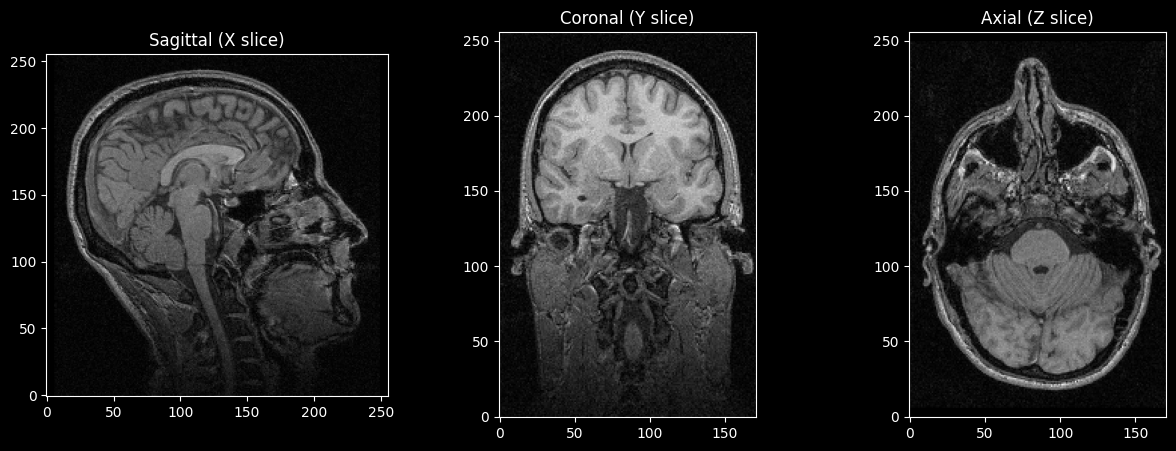

In [2]:
x, y, z = np.array(data.shape) // 2

fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(data[x,:,:].T, cmap="gray", origin="lower")
axes[0].set_title("Sagittal (X slice)")

axes[1].imshow(data[:,y,:].T, cmap="gray", origin="lower")
axes[1].set_title("Coronal (Y slice)")

axes[2].imshow(data[:,:,z].T, cmap="gray", origin="lower")
axes[2].set_title("Axial (Z slice)")

plt.show()


# Intensity Histogram

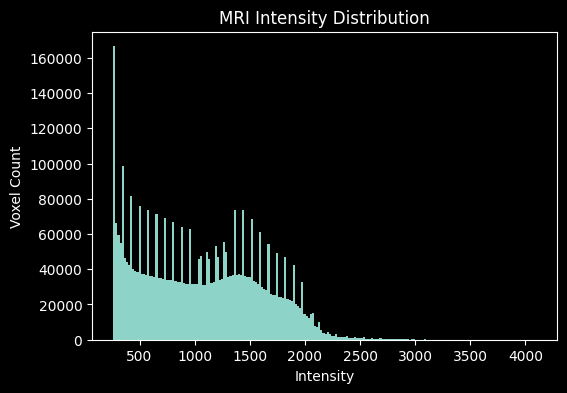

In [3]:
plt.figure(figsize=(6,4))
plt.hist(data[data>250].ravel(), bins=200)
plt.title("MRI Intensity Distribution")
plt.xlabel("Intensity")
plt.ylabel("Voxel Count")
plt.show()

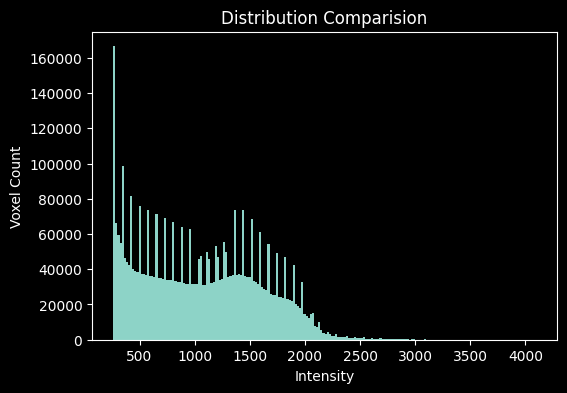

In [6]:
# fmri_path = "../data/SIMON_data/SIMON_BIDS/sub-032633/ses-071/anat/sub-032633_ses-071_run-1_T1w.nii.gz"
img2 = nib.load(fmri_path)
data2 = img.get_fdata()

plt.figure(figsize=(6,4))
plt.hist(data2[data2>250].ravel(), bins=200)
plt.title("Distribution Comparision")
plt.xlabel("Intensity")
plt.ylabel("Voxel Count")
plt.show()

# Intensity Windowing

Intensity Windowing: MRI data often has a high dynamic range (e.g., 12-bit or 16-bit), while human eyes and standard monitors can only discern limited shades of grey. Windowing allows us to "zoom in" on the contrast of specific tissues (like the brain) while ignoring irrelevant data (like the dark background or bright fat).

**Window Width (WW)**: This represents the range of intensities being displayed.

A narrow width increases contrast (makes the image "sharper" or more "black and white"), which is useful for distinguishing between similar tissues like Grey Matter and White Matter.

A wide width shows more types of tissue but reduces the contrast between them.

**Window Level (WL)**: This is the center of the window.

It determines the overall brightness of the image.

You set the WL to the average intensity of the tissue you are interested in. For example, to see the brain, you set the WL near the Grey Matter peak; to see the skull/bone, you would set it to a higher value.

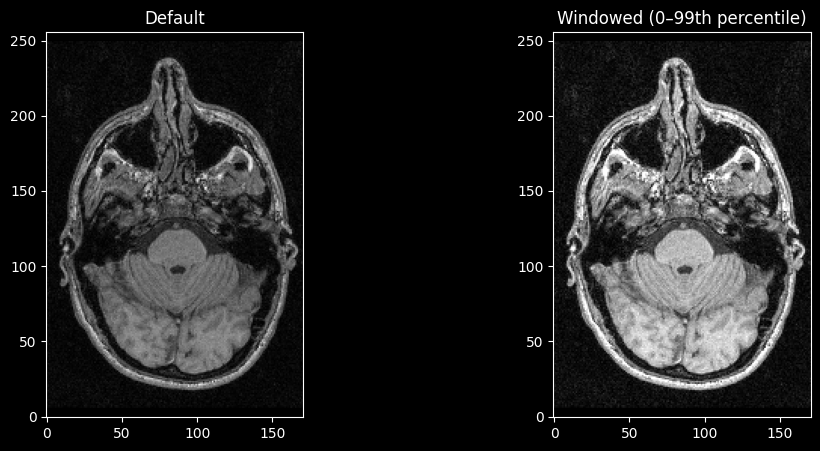

In [7]:
slice_axial = data[:,:,z]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(slice_axial.T, cmap="gray", origin="lower")
plt.title("Default")

plt.subplot(1,2,2)
plt.imshow(slice_axial.T, cmap="gray", vmin=0, vmax=np.percentile(data, 99), origin="lower")
plt.title("Windowed (0–99th percentile)")
plt.show()

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

slice_idx = data.shape[2] // 2
sample_slice = data[:, :, slice_idx].T

def interactive_windowing(vmin, vmax):
    plt.figure(figsize=(10, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(sample_slice, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
    plt.title(f"Windowed Image\n(vmin={vmin}, vmax={vmax})")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.hist(data[data > 10].ravel(), bins=100, color='gray', alpha=0.5)
    plt.axvline(vmin, color='red', linestyle='--', label='vmin')
    plt.axvline(vmax, color='green', linestyle='--', label='vmax')
    plt.title("Intensity Distribution & Window")
    plt.legend()
    plt.xlim(0, np.percentile(data, 99.9)) # x axis
    
    plt.tight_layout()
    plt.show()


max_limit = int(np.percentile(data, 99.9))

widgets.interact(
    interactive_windowing,
    vmin=widgets.IntSlider(min=0, max=max_limit, step=10, value=0, description='vmin (Black)'),
    vmax=widgets.IntSlider(min=0, max=max_limit, step=10, value=int(np.percentile(data, 95)), description='vmax (White)')
);

interactive(children=(IntSlider(value=0, description='vmin (Black)', max=2540, step=10), IntSlider(value=1708,…

# Nilearn Anatomical Plot

Unlike standard Matplotlib imshow, Nilearn handles the **affine matrix** (the mathematical coordinates that tell the computer where the brain is in 3D space) automatically.

| Function | What it does | Best Use Case |
| :--- | :--- | :--- |
| `plotting.plot_anat` | Displays a T1/structural scan in 3 views (Ortho). | Standard visualization of anatomy. |
| `plotting.plot_roi` | Overlays a "Region of Interest" (mask) on the brain. | Visualizing Step 05 (Segmentation). |
| `plotting.plot_epi` | Visualizing fMRI (functional) data. | If you expand your project to functional MRI. |
| `plotting.view_img` | Creates an interactive 3D viewer in your browser. | Exploring the whole volume without slicing manually. 

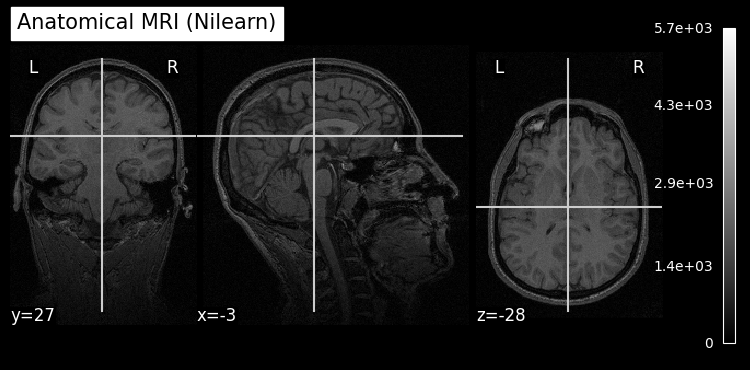

In [9]:
plotting.plot_anat(img, title="Anatomical MRI (Nilearn)")
plotting.show()

🧠 What plot_anat(img) Automatically Handles

Nilearn uses the affine matrix and header info to correctly display the brain in anatomical (RAS) space.

| Step                  | What Nilearn Does                            | Why It Matters                                     |
| --------------------- | -------------------------------------------- | -------------------------------------------------- |
| 1️⃣ Load affine       | Uses `img.affine`                            | Knows how voxel axes map to real space             |
| 2️⃣ Reorient image    | Converts data to **RAS+ orientation**        | Ensures Left/Right, Anterior/Posterior are correct |
| 3️⃣ Select cut coords | Chooses slices in **world (mm) coordinates** | Not voxel index based                              |
| 4️⃣ Aspect ratio      | Scales axes using voxel size (`pixdim`)      | Prevents distorted brain shape                     |
| 5️⃣ Intensity scaling | Robust auto contrast (percentile-based)      | Improves visibility                                |
| 6️⃣ Display mode      | Shows orthogonal anatomical slices           | Research-standard view                             |


## try to use matplotlib to mimic what Nilearn does, but failed

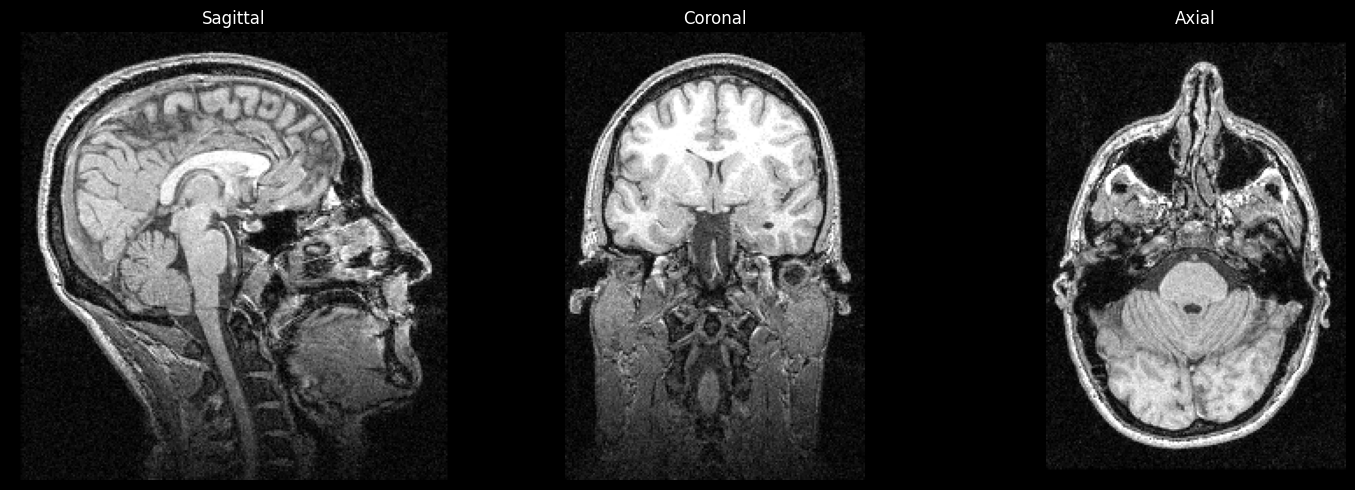

In [10]:
import nibabel as nib
from nibabel.orientations import axcodes2ornt, ornt_transform, aff2axcodes

# Convert to closest canonical (RAS+) orientation
img_ras = nib.as_closest_canonical(img)

data = img_ras.get_fdata()
affine = img_ras.affine

x, y, z = np.array(data.shape) // 2

vmin, vmax = np.percentile(data[data > 0], [2, 98])

zooms = img_ras.header.get_zooms()[:3]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sagittal
axes[0].imshow(data[x, :, :].T, cmap="gray",
               vmin=vmin, vmax=vmax,
               origin="lower",
               aspect=zooms[2]/zooms[1])
axes[0].set_title("Sagittal")

# Coronal
axes[1].imshow(data[:, y, :].T, cmap="gray",
               vmin=vmin, vmax=vmax,
               origin="lower",
               aspect=zooms[2]/zooms[0])
axes[1].set_title("Coronal")

# Axial
axes[2].imshow(data[:, :, z].T, cmap="gray",
               vmin=vmin, vmax=vmax,
               origin="lower",
               aspect=zooms[1]/zooms[0])
axes[2].set_title("Axial")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# World Coordinate Visualization

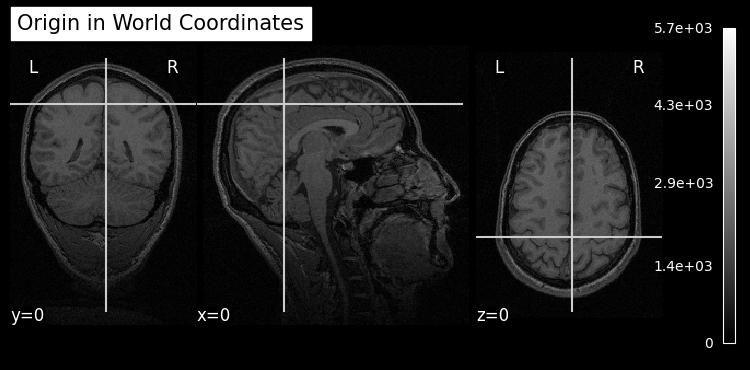

In [11]:
coords = (0, 0, 0)
plotting.plot_anat(img, cut_coords=coords, title="Origin in World Coordinates")
plotting.show()

# Brain Mask Overlay

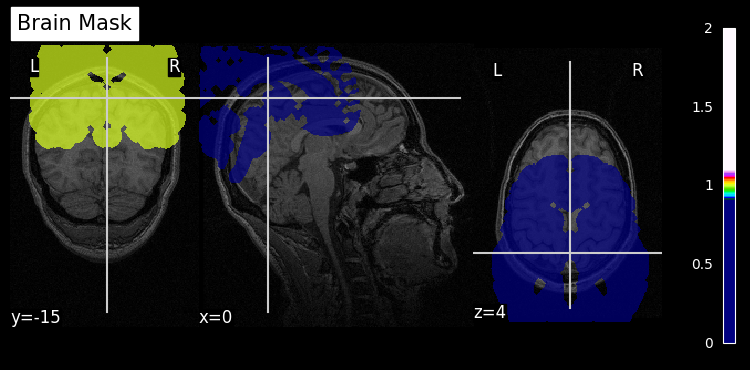

In [12]:
from nilearn.masking import compute_brain_mask

mask = compute_brain_mask(img)

plotting.plot_roi(mask, bg_img=img, title="Brain Mask")
plotting.show()

This is be like: wow something must went wrong

In [13]:
print(f"Image shape: {img.shape}")
print(f"Mask shape: {mask.shape}")
print(f"Image Affine:\n{img.affine}")
print(f"Mask Affine:\n{mask.affine}")

Image shape: (171, 256, 256)
Mask shape: (171, 256, 256)
Image Affine:
[[  -1.           -0.           -0.           82.60935974]
 [  -0.            1.           -0.          -79.69107056]
 [   0.            0.            1.         -200.95272827]
 [   0.            0.            0.            1.        ]]
Mask Affine:
[[  -1.           -0.           -0.           82.60935974]
 [  -0.            1.           -0.          -79.69107056]
 [   0.            0.            1.         -200.95272827]
 [   0.            0.            0.            1.        ]]


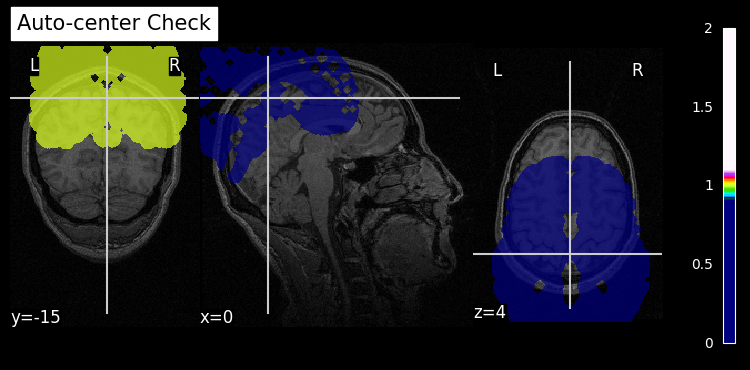

In [36]:
from nilearn.image import threshold_img

# Create a version of the image where extreme outliers are removed
# This helps the masking algorithm 'see' the brain peaks better
img_clipped = threshold_img(img, threshold=20, copy=True) 
# Note: You can also manually clip: data[data > 2000] = 2000


mask = compute_brain_mask(img_clipped, opening=3) # 'opening' cleans up small noise pixels
plotting.plot_roi(mask, bg_img=img, 
                  cut_coords=None, # This tells Nilearn to find the 'cut' automatically
                  display_mode='ortho', 
                  title="Auto-center Check")
plotting.show()

In [46]:
from nilearn import plotting

# 这会生成一个网页交互界面，你可以拉动进度条查看
view = plotting.view_img(mask, bg_img=img, opacity=0.5)
view.open_in_browser() # 或者直接在 notebook 里显示 view

/Users/hersey/miniconda3/envs/mri/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


In [15]:
# Check how many voxels are actually in your mask
print(f"Total voxels in mask: {np.sum(mask.get_fdata())}")
print(f"Percentage of volume covered: {100 * np.sum(mask.get_fdata()) / np.prod(mask.shape):.2f}%")

Total voxels in mask: 1426922.0
Percentage of volume covered: 12.73%


In [37]:
print("Original affine:\n", img.affine)
print("Clipped affine:\n", img_clipped.affine)
print("Mask affine:\n", mask.affine)


Original affine:
 [[  -1.           -0.           -0.           82.60935974]
 [  -0.            1.           -0.          -79.69107056]
 [   0.            0.            1.         -200.95272827]
 [   0.            0.            0.            1.        ]]
Clipped affine:
 [[  -1.           -0.           -0.           82.60935974]
 [  -0.            1.           -0.          -79.69107056]
 [   0.            0.            1.         -200.95272827]
 [   0.            0.            0.            1.        ]]
Mask affine:
 [[  -1.           -0.           -0.           82.60935974]
 [  -0.            1.           -0.          -79.69107056]
 [   0.            0.            1.         -200.95272827]
 [   0.            0.            0.            1.        ]]


In [39]:
import nibabel as nib
print(nib.aff2axcodes(img.affine))


('L', 'A', 'S')


In [45]:
import numpy as np
from scipy.ndimage import center_of_mass

mask_data = mask.get_fdata()
com_voxel = center_of_mass(mask_data)

print("Center of brain mask (voxel space):", com_voxel)
print("Image center (voxel space):", np.array(mask_data.shape)/2)


Center of brain mask (voxel space): (np.float64(87.39176633340855), np.float64(64.44363532134201), np.float64(205.28366582055642))
Image center (voxel space): [ 85.5 128.  128. ]


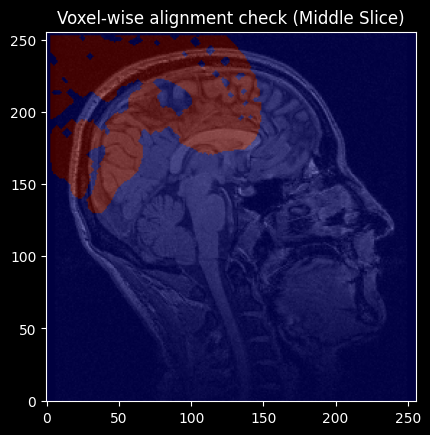

In [16]:
# Manually pick a slice in the middle of your 171x256x256 matrix
# This bypasses the mm coordinates and looks at the raw voxels
img_data = img.get_fdata()
mask_data = mask.get_fdata()

plt.imshow(img_data[85, :, :].T, cmap='gray', origin='lower')
plt.imshow(mask_data[85, :, :].T, cmap='jet', alpha=0.5, origin='lower')
plt.title("Voxel-wise alignment check (Middle Slice)")
plt.show()

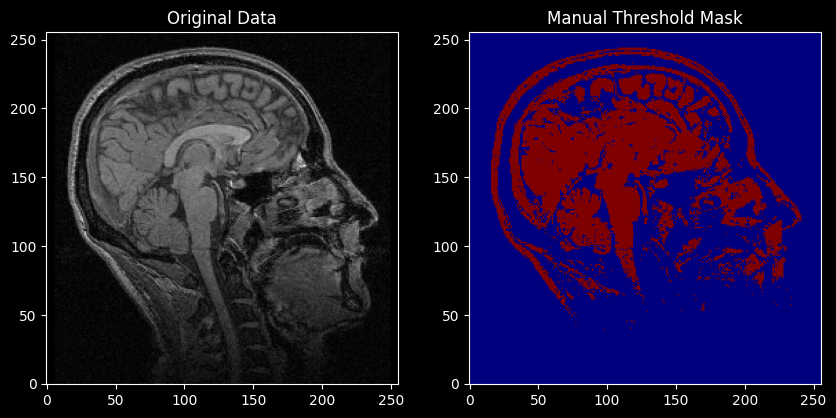

In [32]:
x_idx = data.shape[0]//2
# Create a mask manually based on histogram's 'Brain Tail'
# Based on your previous plot, brain tissue seems to live between 400 and 2000
data = img.get_fdata()
manual_mask = np.zeros_like(data)
manual_mask[(data > 1000) & (data < 2800)] = 1

# Check a slice manually
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(data[x_idx, :, :].T, cmap='gray', origin='lower')
plt.title("Original Data")

plt.subplot(1, 2, 2)
plt.imshow(manual_mask[x_idx, :, :].T, cmap='jet', origin='lower')
plt.title("Manual Threshold Mask")
plt.show()

# Slice Grid Overview

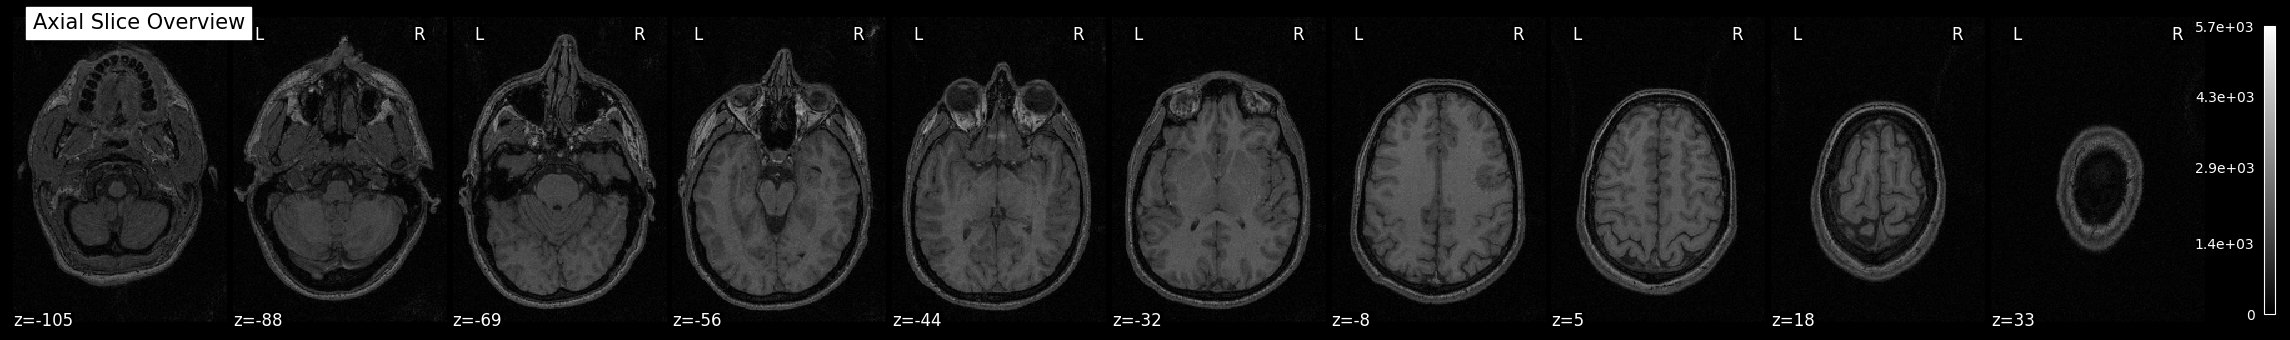

In [18]:
plotting.plot_anat(img, display_mode="z", cut_coords=10, title="Axial Slice Overview")
plotting.show()

# Intensity Across Slices

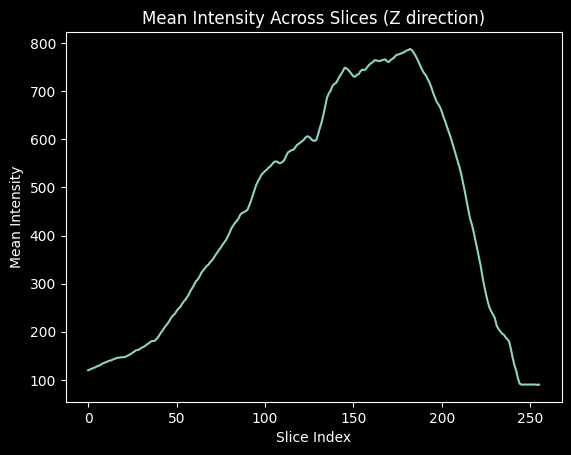

In [19]:
means = [data[:,:,i].mean() for i in range(data.shape[2])]

plt.plot(means)
plt.title("Mean Intensity Across Slices (Z direction)")
plt.xlabel("Slice Index")
plt.ylabel("Mean Intensity")
plt.show()
